## compare CapHLA to other state-of-art method

In [41]:
import pandas as pd
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
def evalute(true_label, pred_score):
    fpr, tpr, _ = roc_curve(true_label, pred_score)
    auroc = auc(fpr, tpr)
    prec, reca, _ = precision_recall_curve(true_label, pred_score)
    auprc = auc(reca, prec)
    return auroc, fpr, tpr, auprc, prec, reca

In [3]:
el_mhc1 = pd.read_csv('./el_external_hla1_all_tools_predict_socre.csv')

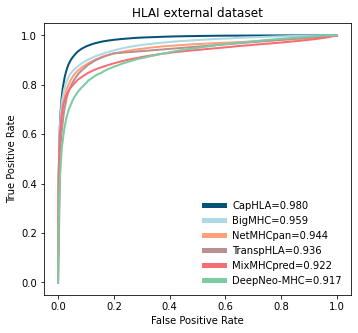

In [5]:
colors = ['#045275',  '#add8e6', '#ffa07a', '#bc8f8f', '#f66e74','#7ccba2']
tools_list = ['CapHLA', 'BigMHC', 'NetMHCpan', 'TranspHLA', 'MixMHCpred', 'DeepNeo-MHC']
fig, ax = plt.subplots(figsize=(5.5, 5))
for i, tool in enumerate(tools_list):
    el_mhc1_tool = el_mhc1.loc[:,['true_label', tool]]
    el_mhc1_tool = el_mhc1_tool[el_mhc1_tool[tool] != 'None']
    el_mhc1_tool.dropna(axis=0, how='any', inplace=True)
    el_mhc1_tool[tool] = el_mhc1_tool[tool].astype('float')
    auroc, fpr, tpr, _, _, _ = evalute(el_mhc1_tool['true_label'], el_mhc1_tool[tool])
    ax.plot(fpr, tpr, label=f'{tool}={auroc:.3f}', color=colors[i], linewidth=2)
leg = plt.legend(loc='lower right', frameon=False)
for line in leg.get_lines():
    line.set_linewidth(5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('HLAI external dataset')
plt.show()

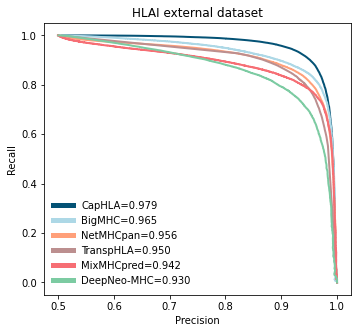

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for i, tool in enumerate(tools_list):
    el_mhc1_tool = el_mhc1.loc[:,['true_label', tool]]
    el_mhc1_tool = el_mhc1_tool[el_mhc1_tool[tool] != 'None']
    el_mhc1_tool.dropna(axis=0, how='any', inplace=True)
    el_mhc1_tool[tool] = el_mhc1_tool[tool].astype('float')
    _, _, _, auprc, prec, reca = evalute(el_mhc1_tool['true_label'], el_mhc1_tool[tool])
    ax.plot(prec, reca, label=f'{tool}={auprc:.3f}', color=colors[i], linewidth=2)
leg = plt.legend(loc='lower left', frameon=False)
for line in leg.get_lines():
    line.set_linewidth(5)
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('HLAI external dataset')
plt.show()

In [7]:
el_mhc1['length'] = el_mhc1['peptide'].apply(len)
tools_list = ['CapHLA', 'BigMHC', 'NetMHCpan', 'TranspHLA', 'MixMHCpred']
length_result = []
for i in range(8, 15):
    for tool in tools_list:
        el_mhc1_tool = el_mhc1.loc[:,['true_label', tool , 'length']]
        el_mhc1_tool = el_mhc1_tool[el_mhc1_tool[tool] != 'None']
        el_mhc1_tool[tool] = el_mhc1_tool[tool].astype('float')
        el_mhc1_tool.dropna(axis=0, how='any', inplace=True)
        el_mhc1_tool = el_mhc1_tool[el_mhc1_tool['length'] == i]
        auroc, _, _, auprc, _, _ = evalute(el_mhc1_tool['true_label'], el_mhc1_tool[tool])
        length_result.append([i, tool, auroc, auprc])
length_result = pd.DataFrame(length_result, columns=['length', 'method', 'AUROC', 'AUPRC'])

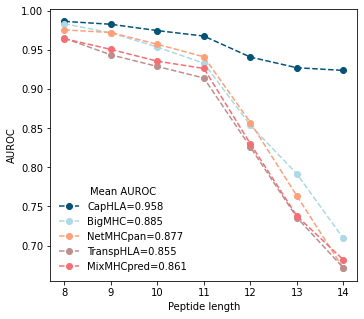

In [8]:
fig = plt.figure(figsize=(5.5, 5))
for i, k in enumerate(tools_list):
    part = length_result[length_result['method'] == k]
    mean = round(part['AUROC'].mean(), 3)
    plt.plot(part['length'], part['AUROC'], 'o--', color=colors[i], label=f'{k}={mean}')
leg = plt.legend(loc='lower left', frameon=False, title='Mean AUROC')
plt.xlabel('Peptide length')
plt.ylabel('AUROC')
plt.show()

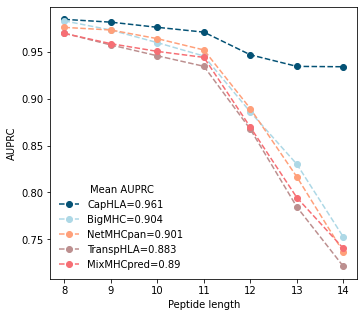

In [10]:
fig = plt.figure(figsize=(5.5, 5))
for i, k in enumerate(tools_list):
    part = length_result[length_result['method'] == k]
    mean = round(part['AUPRC'].mean(), 3)
    plt.plot(part['length'], part['AUPRC'], 'o--', color=colors[i], label=f'{k}={mean}')
leg = plt.legend(loc='lower left', frameon=False, title='Mean AUPRC')
plt.xlabel('Peptide length')
plt.ylabel('AUPRC')
plt.show()

In [11]:
el_mhc2 = pd.read_csv('el_external_hla2_all_tools_predict_socre.csv')

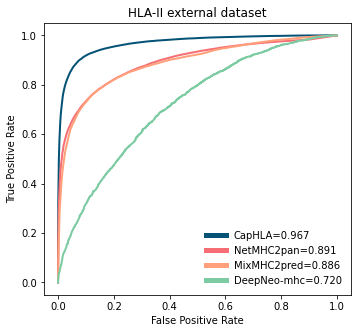

In [12]:
colors = ['#045275','#f66e74', '#ffa07a',  '#7ccba2']
tools_list = ['CapHLA', 'NetMHC2pan', 'MixMHC2pred','DeepNeo-mhc']
fig, ax = plt.subplots(figsize=(5.5, 5))
for i, tool in enumerate(tools_list):
    el_mhc2_tool = el_mhc2.loc[:,['true_label', tool]]
    el_mhc2_tool = el_mhc2_tool[el_mhc2_tool[tool] != 'None']
    el_mhc2_tool.dropna(axis=0, how='any', inplace=True)
    el_mhc2_tool[tool] = el_mhc2_tool[tool].astype('float')
    auroc, fpr, tpr, _, _, _ = evalute(el_mhc2_tool['true_label'], el_mhc2_tool[tool])
    ax.plot(fpr, tpr, label=f'{tool}={auroc:.3f}', color=colors[i], linewidth=2)
leg = plt.legend(loc='lower right', frameon=False)
for line in leg.get_lines():
    line.set_linewidth(5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('HLA-II external dataset')
plt.show()

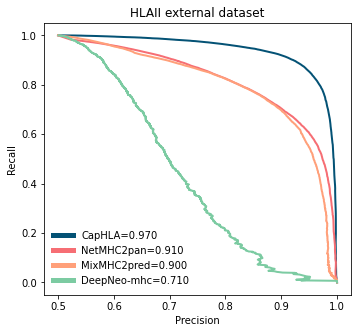

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for i, tool in enumerate(tools_list):
    el_mhc2_tool = el_mhc2.loc[:,['true_label', tool]]
    el_mhc2_tool = el_mhc2_tool[el_mhc2_tool[tool] != 'None']
    el_mhc2_tool.dropna(axis=0, how='any', inplace=True)
    el_mhc2_tool[tool] = el_mhc2_tool[tool].astype('float')
    _, _, _, auprc, prec, reca = evalute(el_mhc2_tool['true_label'], el_mhc2_tool[tool])
    ax.plot(prec, reca, label=f'{tool}={auprc:.3f}', color=colors[i], linewidth=2)
leg = plt.legend(loc='lower left', frameon=False)
for line in leg.get_lines():
    line.set_linewidth(5)
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('HLAII external dataset')
plt.show()

In [14]:
el_mhc2['length'] = el_mhc2['peptide'].apply(len)
tools_list = ['CapHLA', 'NetMHC2pan', 'MixMHC2pred']
length_result2 = []
for i in range(13, 22):
    for tool in tools_list:
        el_mhc2_tool = el_mhc2.loc[:,['true_label', tool , 'length']]
        el_mhc2_tool = el_mhc2_tool[el_mhc2_tool[tool] != 'None']
        el_mhc2_tool[tool] = el_mhc2_tool[tool].astype('float')
        el_mhc2_tool.dropna(axis=0, how='any', inplace=True)
        el_mhc2_tool = el_mhc2_tool[el_mhc2_tool['length'] == i]
        auroc, _, _, auprc, _, _ = evalute(el_mhc2_tool['true_label'], el_mhc2_tool[tool])
        length_result2.append([i, tool, auroc, auprc])
length_result2 = pd.DataFrame(length_result2, columns=['length', 'method', 'AUROC', 'AUPRC'])

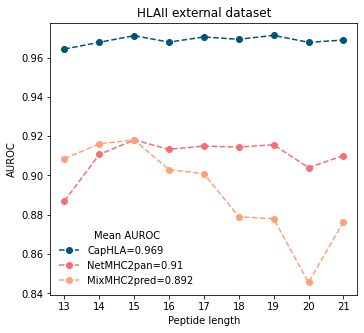

In [15]:
fig = plt.figure(figsize=(5.5, 5))
for i, k in enumerate(tools_list):
    part = length_result2[length_result2['method'] == k]
    mean = round(part['AUROC'].mean(), 3)
    plt.plot(part['length'], part['AUROC'], 'o--', color=colors[i], label=f'{k}={mean}')
leg = plt.legend(loc='lower left', frameon=False, title='Mean AUROC')
plt.xlabel('Peptide length')
plt.ylabel('AUROC')
plt.title('HLAII external dataset')
plt.show()

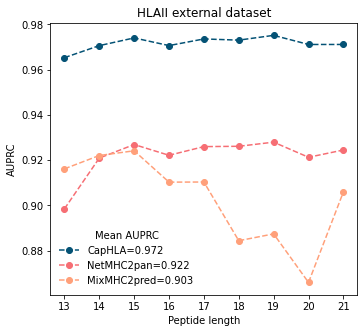

In [16]:
fig = plt.figure(figsize=(5.5, 5))
for i, k in enumerate(tools_list):
    part = length_result2[length_result2['method'] == k]
    mean = round(part['AUPRC'].mean(), 3)
    plt.plot(part['length'], part['AUPRC'], 'o--', color=colors[i], label=f'{k}={mean}')
leg = plt.legend(loc='lower left', frameon=False, title='Mean AUPRC')
plt.xlabel('Peptide length')
plt.ylabel('AUPRC')
plt.title('HLAII external dataset')
plt.show()

In [18]:
ba_hla1 = pd.read_csv('ba_external_hla1_all_tools_predict_socre.csv')

In [19]:
tools_list = ['CapHLA', 'ANN', 'NetMHCpan_BA', 'PickPocket']
mhc1_eva = pd.DataFrame(index=['mse', 'mae', 'r2'])
for tool in tools_list:
    ba_hla1_tool = ba_hla1.loc[:,['true_score', tool]]
    ba_hla1_tool = ba_hla1_tool[ba_hla1_tool[tool] != 'None']
    ba_hla1_tool.dropna(axis=0, how='any', inplace=True)
    ba_hla1_tool[tool] = ba_hla1_tool[tool].astype('float')
    mae = mean_absolute_error(ba_hla1_tool['true_score'], ba_hla1_tool[tool])
    r2 = r2_score(ba_hla1_tool['true_score'], ba_hla1_tool[tool])
    mse = mean_squared_error(ba_hla1_tool['true_score'], ba_hla1_tool[tool])
    mhc1_eva[tool] = [mse, mae, r2]

mhc1_eva['index'] = mhc1_eva.index
mhc1_eva_long = mhc1_eva.melt(id_vars='index', var_name='tools', value_name='value')
mhc1_eva_long['value'] = mhc1_eva_long['value'].apply(
    lambda x: round(x, 4))

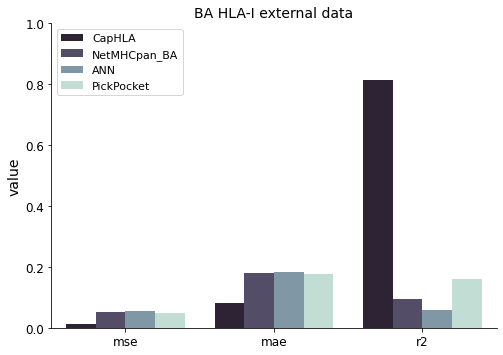

In [20]:
palette = ['#2f2037', '#50486d', '#799aad', '#bde2d5']
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('BA HLA-I external data', fontsize=14)
sns.barplot(x='index', y='value', data=mhc1_eva_long,
            hue='tools', linewidth=0,
            palette=palette, ax=ax,
            capsize=0.2, errwidth=2,
            hue_order=['CapHLA', 'NetMHCpan_BA', 'ANN', 'PickPocket']) #
ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left')
plt.tight_layout()
plt.legend(fontsize=11)
plt.xticks(size=12)
plt.yticks(size=12)
plt.ylabel('value', size=14)
plt.show()

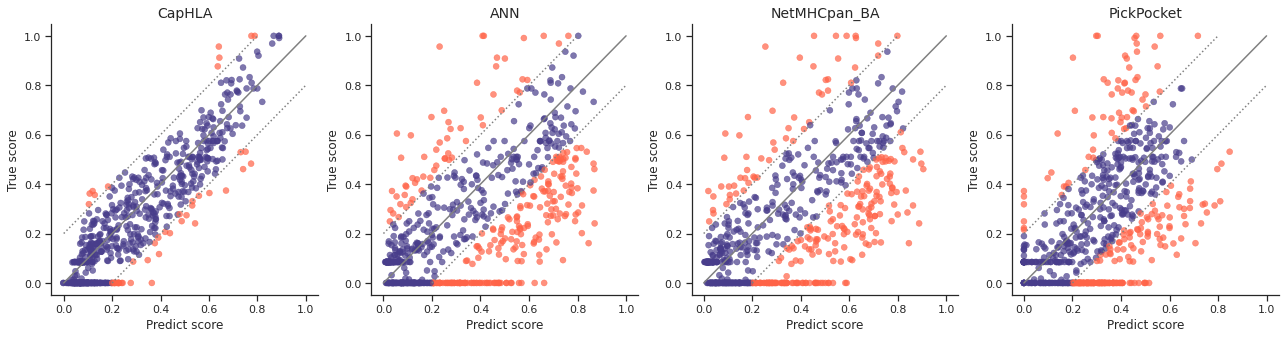

In [22]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
colors = ['#483d8b', 'tomato']
fig, ax = plt.subplots(figsize=(5.5*len(tools_list), 5), ncols=len(tools_list))
for i in range(len(tools_list)):
    tool = tools_list[i]
    ba_hla1_tool = ba_hla1.loc[:,['true_score', tool]]
    ba_hla1_tool = ba_hla1_tool[ba_hla1_tool[tool] != 'None']
    ba_hla1_tool.dropna(axis=0, how='any', inplace=True)
    ba_hla1_tool[tool] = ba_hla1_tool[tool].astype('float')
    ba_hla1_tool['label'] = ba_hla1_tool.apply(
        lambda x: 'close' if math.fabs(x['true_score'] - x[tool]) <= 0.2 else 'far', axis=1)

    sns.scatterplot(data=ba_hla1_tool, x=tool, y='true_score',
                    ax=ax[i], hue='label', palette=colors, alpha=0.7,
                    hue_order=['close', 'far'],edgecolor=None, legend=None)
    ax[i].plot((0, 1), (0, 1), '-', color='grey')
    ax[i].plot((0, 0.8), (0.2, 1), ':', color='grey')
    ax[i].plot((0.2, 1), (0, 0.8), ':', color='grey')
    ax[i].set_xlabel('Predict score')
    ax[i].set_ylabel('True score')
    ax[i].set_title(f'{tool}', size=14)
plt.show()

In [23]:
ba_hla2 = pd.read_csv('ba_external_hla2_all_tools_predict_socre.csv')
tools_list = ['CapHLA', 'NetMHCIIpan_BA', 'NN_align', 'SMM_align']
mhc2_eva = pd.DataFrame(index=['mse', 'mae', 'r2'])
for tool in tools_list:
    ba_hla2_tool = ba_hla2.loc[:,['true_score', tool]]
    ba_hla2_tool = ba_hla2_tool[ba_hla2_tool[tool] != 'None']
    ba_hla2_tool.dropna(axis=0, how='any', inplace=True)
    ba_hla2_tool[tool] = ba_hla2_tool[tool].astype('float')
    mae = mean_absolute_error(ba_hla2_tool['true_score'], ba_hla2_tool[tool])
    r2 = r2_score(ba_hla2_tool['true_score'], ba_hla2_tool[tool])
    mse = mean_squared_error(ba_hla2_tool['true_score'], ba_hla2_tool[tool])
    mhc2_eva[tool] = [mse, mae, r2]

mhc2_eva['index'] = mhc2_eva.index
mhc2_eva_long = mhc2_eva.melt(id_vars='index', var_name='tools', value_name='value')
mhc2_eva_long['value'] = mhc2_eva_long['value'].apply(
    lambda x: round(x, 4))

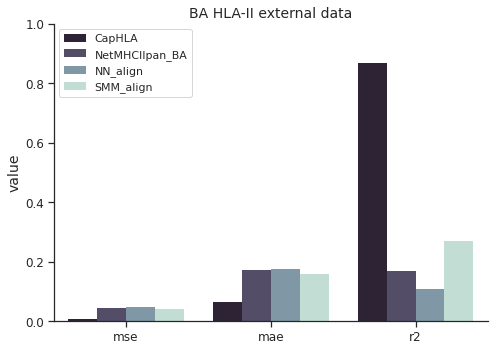

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('BA HLA-II external data', fontsize=14)
sns.barplot(x='index', y='value', data=mhc2_eva_long,
            hue='tools', linewidth=0,
            palette=palette, ax=ax,
            capsize=0.2, errwidth=2,
            hue_order=['CapHLA', 'NetMHCIIpan_BA', 'NN_align', 'SMM_align']) #
ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left')
plt.tight_layout()
plt.legend(fontsize=11)
plt.xticks(size=12)
plt.yticks(size=12)
plt.ylabel('value', size=14)
plt.show()

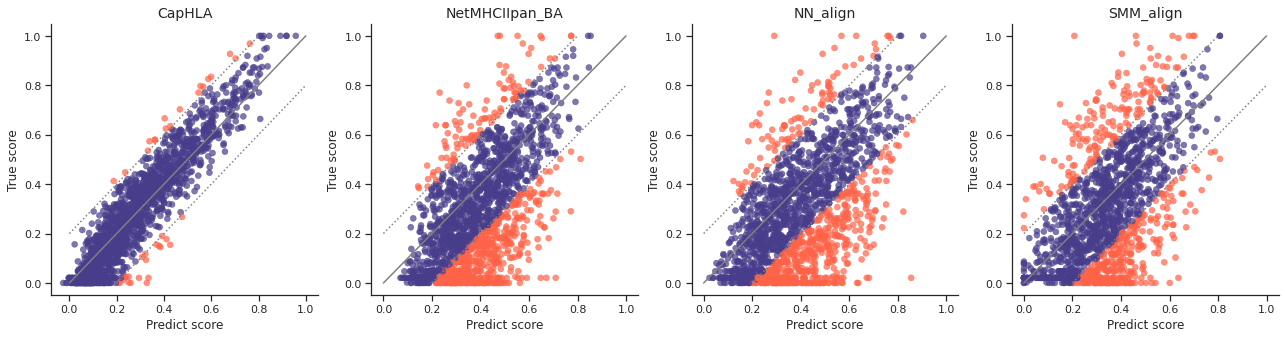

In [25]:
fig, ax = plt.subplots(figsize=(5.5*len(tools_list), 5), ncols=len(tools_list))
for i in range(len(tools_list)):
    tool = tools_list[i]
    ba_hla2_tool = ba_hla2.loc[:,['true_score', tool]]
    ba_hla2_tool = ba_hla2_tool[ba_hla2_tool[tool] != 'None']
    ba_hla2_tool.dropna(axis=0, how='any', inplace=True)
    ba_hla2_tool[tool] = ba_hla2_tool[tool].astype('float')
    ba_hla2_tool['label'] = ba_hla2_tool.apply(
        lambda x: 'close' if math.fabs(x['true_score'] - x[tool]) <= 0.2 else 'far', axis=1)

    sns.scatterplot(data=ba_hla2_tool, x=tool, y='true_score',
                    ax=ax[i], hue='label', palette=colors, alpha=0.7,
                    hue_order=['close', 'far'],edgecolor=None, legend=None)
    ax[i].plot((0, 1), (0, 1), '-', color='grey')
    ax[i].plot((0, 0.8), (0.2, 1), ':', color='grey')
    ax[i].plot((0.2, 1), (0, 0.8), ':', color='grey')
    ax[i].set_xlabel('Predict score')
    ax[i].set_ylabel('True score')
    ax[i].set_title(f'{tool}', size=14)
plt.show()